#### Vendor TimeView Model on Simulated Tumour Data

This implementation runs on data:
- with no unobserved heteroegeneity in the DGP,
- with no observational noise, 
- with equally spaced observations for all individuals. 

In [37]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import pytorch_lightning as pl
import optuna

project_root = Path.cwd().parents[2]
sys.path.insert(0, str(project_root))

# Functions needed for data generation
from scripts.shape_uncertainty.simulated_data.data_generator import WilkersonDGP
from scripts.shape_uncertainty.simulated_data.data_generator import generate_simulated_dataset
from scripts.shape_uncertainty.spline_basis.bspline_basis import build_knot_dictionary

# Functions needed to run the timeview model
from scripts.shape_uncertainty.experiments.timeview_helpers import (
    run_timeview_optuna_trial, best_timeview_hyperparams, train_final_timeview_model,
    save_timeview_run, load_timeview_run, TimeViewInferenceEngine,
)

# Functions needed for shape extraction
from scripts.shape_uncertainty.model.model_evaluation import ModelEvaluator
from scripts.shape_uncertainty.simulated_data.shape_ground_truth import get_analytic_shape_summary
from scripts.shape_uncertainty.shape_extraction.shape_distance import (
    exact_shape_sequence_match,
    shape_summary_distance,
    mean_shape_sequence_match,
    mean_shape_summary_distance,
)

# Helpers needed for plotting
from scripts.shape_uncertainty.experiments.plot_helpers import plot_individual_diagnostic


# Supressing error messages
import logging
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)

import warnings
warnings.filterwarnings("ignore", ".*does not have many workers.*")

In [39]:
# Helper
def evaluate_extraction(engine, dataset, u1_rel, u2_rel, upsilon_rel_prune, do_prune):
    """Extract shape summaries from a trained engine and score against ground truth."""
    predicted = [engine.predict_mean_shape_summary(x)
                 for x in dataset.individual_covariates()]
    true = get_analytic_shape_summary(dataset, u1_rel, u2_rel, upsilon_rel_prune, do_prune)
    accuracy = mean_shape_sequence_match(predicted, true)
    distance = mean_shape_summary_distance(predicted, true, dataset.T)
    return {"predicted": predicted, "true": true,
            "accuracy": accuracy, "distance": distance}

def _shape_states(summary):
    return [state for state, _ in summary]

def _transition_times(summary):
    return [f"{time:.4f}" for _, time in summary]

def per_patient_table(result, patients, T):
    """Per-patient shape summaries with per-patient match and distance."""
    rows = []
    for i in patients:
        pred, true = result["predicted"][i], result["true"][i]
        rows.append({
            "patient": i,
            "true_summary": _shape_states(true),
            "predicted_summary": _shape_states(pred),
            "match": exact_shape_sequence_match(pred, true),
            "distance": round(shape_summary_distance(pred, true, T), 3),
            "true_transitions": _transition_times(true),
            "predicted_transitions": _transition_times(pred),
        })
    return pd.DataFrame(rows)

#### Step 1: Generate a dataset

In [38]:
# Data-generating process
T = 1.0
ALPHA_G, ALPHA_D = 0.0, 0.0 # 0 = no unobserved heterogeneity
HYPERPARAMS = {"g0": 2.0, "d0": 180.0, "rho0": 10.0,
               "alpha_g": ALPHA_G, "alpha_d": ALPHA_D}

# Observation design 
NR_OBS = 20 # observations per individual
SIGMA = 0.0 # measurement-noise std
REGULAR = True
SEED = 42

# Dataset sizes
D_TRAIN, D_VAL, D_TEST = 2000, 1000, 1000
D_TOTAL = D_TRAIN + D_VAL + D_TEST

# Spline basis
NR_INTERIOR_KNOTS = 5 # B = K + 4 = 9, matches TimeView


In [40]:
# Specify the configuration for the data generating process 
dgp = WilkersonDGP(
        T=T, 
        hyperparams=HYPERPARAMS,
        ranges=None, # set to default
)
# Create a dataset from the specified DGP 
dataset = generate_simulated_dataset(
                dgp, 
                D=D_TOTAL,
                N=NR_OBS, 
                sigma=SIGMA, 
                regular=REGULAR,
                include_endpoints=True,
                seed=SEED
)

# Split the dataset into test, validation and training sets 
test, val, train = dataset.split_test_val_train(D_train=D_TRAIN, D_val=D_VAL, D_test=D_TEST)

print("train/val/test:", train.D, val.D, test.D, "- sigma:", train.gen_config["sigma"])

train/val/test: 2000 1000 1000 - sigma: 0.0


In [ ]:
# Print the top 5 lines of the dataset


#### Step 2: Train a TimeView on the tumour dataset

In [41]:
# Define the basis dimension for the model based on NR_INTERIOR_KNOTS
knot_objects = build_knot_dictionary(nr_interior_knots=NR_INTERIOR_KNOTS, T=T)
NR_BASIS = knot_objects["nr_basis"]

In [42]:
# Run Optuna search on a specified search space and retrain the best config
SEARCH_SPACE = {
    "hidden_sizes": {"nr_layers": 3, "low": 16, "high": 128},
    "activation": ["relu", "sigmoid", "tanh", "leaky_relu", "elu", "selu"],
    "dropout": {"low": 0.0, "high": 0.5},
    "lr": {"low": 1e-4, "high": 1e-1, "log": True},
    "batch_size": [64, 128],
    "weight_decay": {"low": 1e-6, "high": 1e-1, "log": True},
}

study = optuna.create_study(direction="minimize")
study.optimize(
    lambda trial: run_timeview_optuna_trial(
                trial, 
                train, 
                val, 
                nr_basis=NR_BASIS, 
                search_space=SEARCH_SPACE,
                epochs=200, 
                patience=10,
    ),
    n_trials=100,
)

# Extract best config and retrain:
best_params = best_timeview_hyperparams(study, SEARCH_SPACE)
tuned = train_final_timeview_model(
    best_params, 
    train, 
    val, 
    nr_basis=NR_BASIS, 
    epochs=200, 
    patience=10,
)
print("best val objective:", round(tuned["best_value"], 3))
print("best params:", best_params)

# Save the trained model
save_timeview_run(tuned, generate_config=train.gen_config, path="trained_models/timeview_baseline")

[I 2026-07-22 01:28:54,455] A new study created in memory with name: no-name-57ad1038-1402-4f30-a2e0-427fa863818c
/Users/richardfranck/venvs/thesis/venv/lib/python3.12/site-packages/pytorch_lightning/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/richardfranck/venvs/thesis/venv/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/richardfranck/venvs/thesis/venv/lib/python3.12/site-packages/pytorch_lightning/utilities/data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 128. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.
/Users/richardfranck/venvs/thesis/venv/lib/python3.12/site-packages/pytorch_lightning/utilities/data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we fo

best val objective: 0.005
best params: {'hidden_sizes': [66, 25, 43], 'activation': 'leaky_relu', 'dropout': 0.002070907470396134, 'lr': 0.012375236876191666, 'batch_size': 128, 'weight_decay': 1.387052503331085e-06}


#### Step 3: Visually inspect model performance on the test set

In [43]:
# Load a trained TimeView model
run = load_timeview_run(path="trained_models/timeview_baseline")

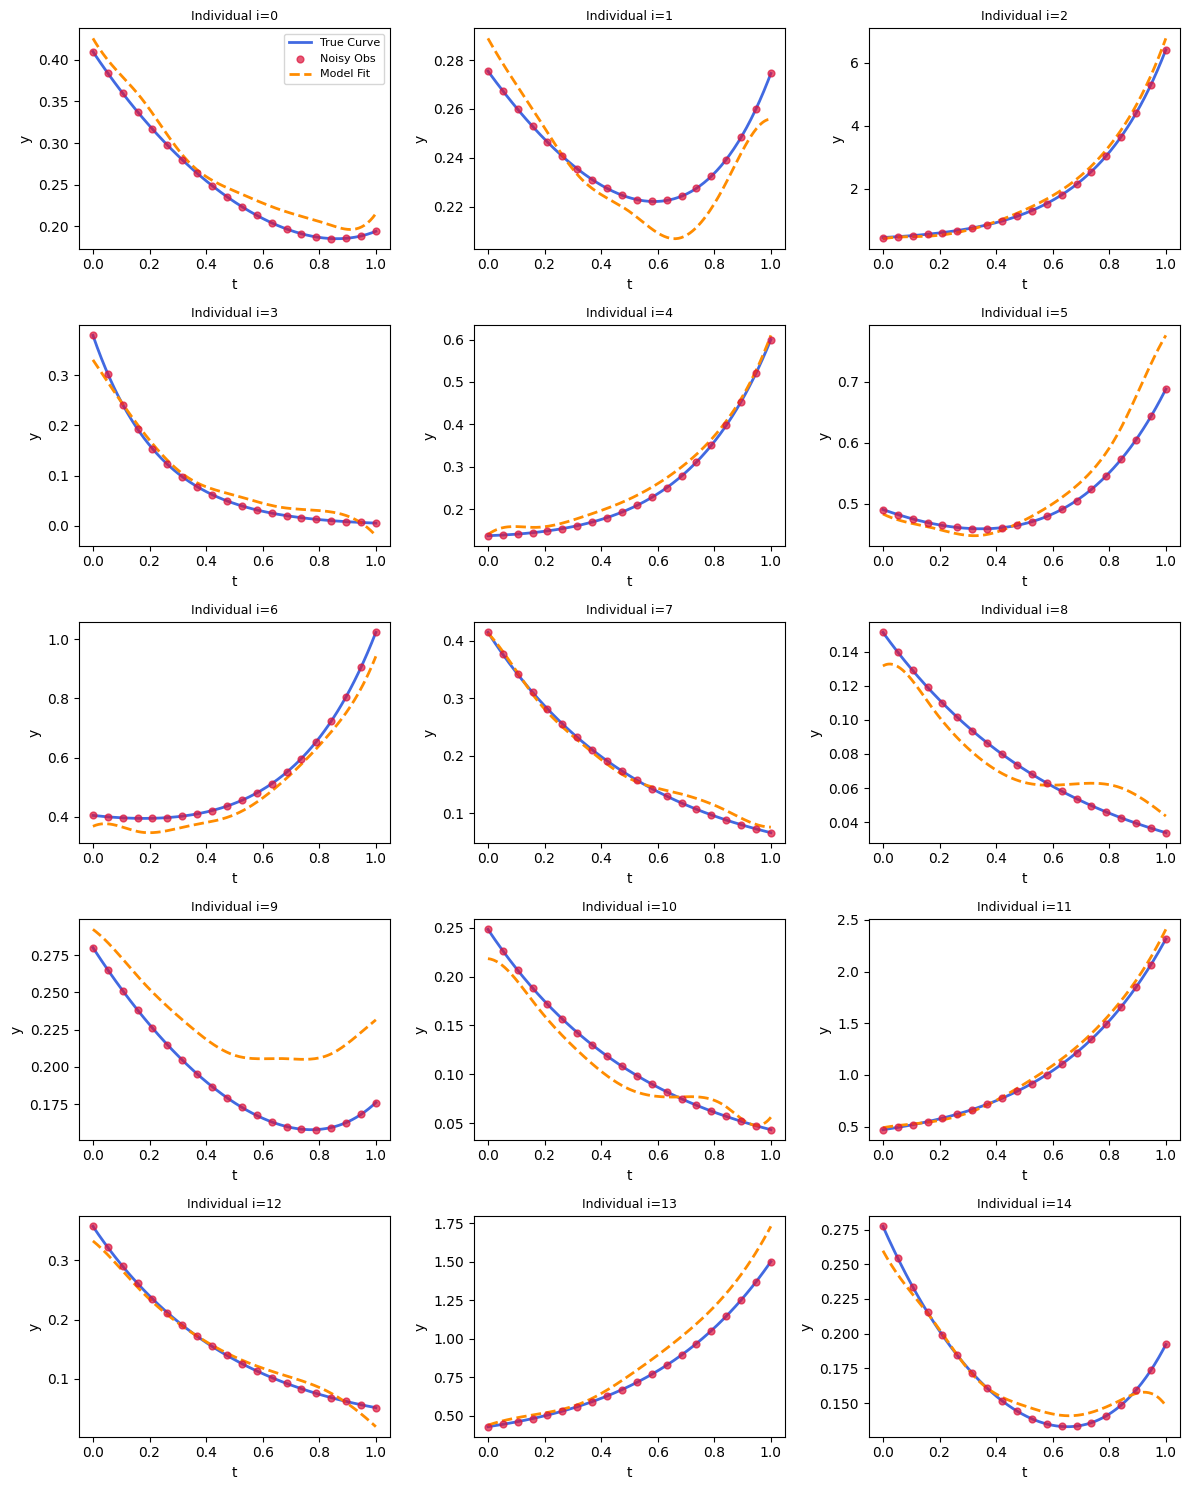

In [44]:
# Plot observations
target_patients = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]

plotting_engine = TimeViewInferenceEngine(
        run["model"], 
        feature_names=list(train.X.keys()),
        C=knot_objects["C"],
        breakpoints=knot_objects["breakpoints"],
        normaliser=run["normaliser"],
)

fig = plot_individual_diagnostic(
    dataset=test,
    indices=target_patients,
    inference_engine=plotting_engine,
    show_true=True,        # 1. Ground truth
    show_noisy=True,       # 2. Noisy observations
    show_estimated=True,   # 3. Trained model
)
plt.show()

#### Step 4: Compute value-space performance metrics

In [45]:
evaluator = ModelEvaluator(inference_engine=plotting_engine, test_dataset=test)
value_metrics = evaluator.compute_value_space_accuracy()
print(f"Value-space RMSE: {value_metrics['rmse']:.4f}")
print(f"Value-space R^2:  {value_metrics['r2']:.4f}")

Value-space RMSE: 0.0334
Value-space R^2:  0.9945


#### Step 5a: Compute shape-space perfromance metrics and inspect shape summaries using the naive shape extractor

In [46]:
# Naive shape extraction
UPSILON_1_REL, UPSILON_2_REL = 0.0, 0.0
ZETA_REL, UPSILON_PRUNE_REL, DO_PRUNE = 0.0, 0.0, False

# Initialise an inference engine 
naive_engine = TimeViewInferenceEngine(
        run["model"], 
        feature_names=list(train.X.keys()),
        C=knot_objects["C"],
        breakpoints=knot_objects["breakpoints"],
        zeta_rel=ZETA_REL,
        upsilon_rel_1=UPSILON_1_REL,
        upsilon_rel_2=UPSILON_2_REL,
        upsilon_rel_prune=UPSILON_PRUNE_REL,
        do_prune=DO_PRUNE,
        normaliser=run["normaliser"],
)

# Get shape-space performance scores
result_naive = evaluate_extraction(naive_engine, test, UPSILON_1_REL, UPSILON_2_REL,
                                UPSILON_PRUNE_REL, DO_PRUNE)

print(f"Exact-sequence-match accuracy: {result_naive['accuracy']:.2f}")
print(f"Mean shape-summary distance:   {result_naive['distance']:.2f}")

Exact-sequence-match accuracy: 0.01
Mean shape-summary distance:   0.14


In [47]:
# Print table of shape summaries for a set of target parients
display(per_patient_table(result_naive, target_patients, test.T))

,patient,true_summary,predicted_summary,match,distance,true_transitions,predicted_transitions
0,0,"[convex_decreasing, convex_increasing]","[convex_decreasing, concave_decreasing, convex...",False,0.109,"[0.0000, 0.8619]","[0.0000, 0.1103, 0.2383, 0.4974, 0.5149, 0.755..."
1,1,"[convex_decreasing, convex_increasing]","[convex_decreasing, concave_decreasing, convex...",False,0.152,"[0.0000, 0.5878]","[0.0000, 0.1219, 0.1957, 0.4389, 0.5417, 0.660..."
2,2,[convex_increasing],"[concave_increasing, convex_increasing]",False,0.036,[0.0000],"[0.0000, 0.1078]"
3,3,[convex_decreasing],"[concave_decreasing, convex_decreasing, concav...",False,0.105,[0.0000],"[0.0000, 0.0042, 0.4787, 0.5448, 0.7550]"
4,4,[convex_increasing],"[concave_increasing, concave_decreasing, conve...",False,0.090,[0.0000],"[0.0000, 0.0933, 0.1287, 0.1641]"
5,5,"[convex_decreasing, convex_increasing]","[convex_decreasing, concave_decreasing, convex...",False,0.071,"[0.0000, 0.3471]","[0.0000, 0.1283, 0.2042, 0.3238, 0.9087]"
6,6,"[convex_decreasing, convex_increasing]","[concave_increasing, concave_decreasing, conve...",False,0.104,"[0.0000, 0.1800]","[0.0000, 0.0424, 0.1162, 0.1993, 0.3031, 0.3757]"
7,7,[convex_decreasing],"[concave_decreasing, convex_decreasing, concav...",False,0.114,[0.0000],"[0.0000, 0.1006, 0.3297, 0.3382, 0.6346, 0.8665]"
8,8,[convex_decreasing],"[concave_increasing, concave_decreasing, conve...",False,0.275,[0.0000],"[0.0000, 0.0237, 0.1467, 0.5884, 0.6662, 0.7371]"
9,9,"[convex_decreasing, convex_increasing]","[concave_decreasing, convex_decreasing, convex...",False,0.140,"[0.0000, 0.7728]","[0.0000, 0.1228, 0.5946, 0.6251, 0.6557, 0.701..."


#### Step 5b: Compute shape-space perfromance metrics and inspect shape summaries using the pruned shape extractor

In [51]:
# Pruned shape extraction
ZETA_REL, UPSILON_PRUNE_REL, DO_PRUNE = 1e-6, 0.05, True

# Initialise an inference engine 
pruning_engine = TimeViewInferenceEngine(
        run["model"], 
        feature_names=list(train.X.keys()),
        C=knot_objects["C"],
        breakpoints=knot_objects["breakpoints"],
        zeta_rel=ZETA_REL,
        upsilon_rel_1=UPSILON_1_REL,
        upsilon_rel_2=UPSILON_2_REL,
        upsilon_rel_prune=UPSILON_PRUNE_REL,
        do_prune=DO_PRUNE,
        normaliser=run["normaliser"],
)

# Get shape-space performance scores
result_pruned = evaluate_extraction(pruning_engine, test, UPSILON_1_REL, UPSILON_2_REL,
                                UPSILON_PRUNE_REL, DO_PRUNE)

print(f"Exact-sequence-match accuracy: {result_pruned['accuracy']:.2f}")
print(f"Mean shape-summary distance:   {result_pruned['distance']:.2f}")

Exact-sequence-match accuracy: 0.78
Mean shape-summary distance:   0.04


In [52]:
# Print table of shape summaries for a set of target parients
display(per_patient_table(result_pruned, target_patients, test.T))

,patient,true_summary,predicted_summary,match,distance,true_transitions,predicted_transitions
0,0,[convex_decreasing],"[convex_decreasing, convex_increasing]",False,0.060,[0.0000],"[0.0000, 0.9099]"
1,1,"[convex_decreasing, convex_increasing]","[convex_decreasing, convex_increasing]",True,0.048,"[0.0000, 0.5878]","[0.0000, 0.6600]"
2,2,[convex_increasing],[convex_increasing],True,0.000,[0.0000],[0.0000]
3,3,[convex_decreasing],"[convex_decreasing, concave_decreasing]",False,0.082,[0.0000],"[0.0000, 0.7550]"
4,4,[convex_increasing],[convex_increasing],True,0.000,[0.0000],[0.0000]
5,5,"[convex_decreasing, convex_increasing]","[convex_decreasing, convex_increasing]",True,0.016,"[0.0000, 0.3471]","[0.0000, 0.3238]"
6,6,[convex_increasing],[convex_increasing],True,0.000,[0.0000],[0.0000]
7,7,[convex_decreasing],[convex_decreasing],True,0.000,[0.0000],[0.0000]
8,8,[convex_decreasing],"[concave_decreasing, convex_decreasing, concav...",False,0.160,[0.0000],"[0.0000, 0.1467, 0.6662]"
9,9,"[convex_decreasing, convex_increasing]","[convex_decreasing, convex_increasing]",True,0.019,"[0.0000, 0.7728]","[0.0000, 0.7446]"
